In [1]:
import pandas as pd
import os
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from utils import get_partition_distances

In [2]:
DIST_PATH = "../data/rnadist_f_all.h5"
dist = pd.read_hdf(DIST_PATH)

splits_path = "./data/5_hl_folds/bkp/"
splits_list = os.listdir(splits_path)
splits_list.sort()
splits_list = splits_list[::2]

splits = {}
for split in splits_list:
    splits[split] = pd.read_csv(splits_path+split)

save_path = "./images/5_hl_folds/bkp/"

In [3]:
print(splits[splits_list[0]].head(2))
dist.head(2)

   fold_name  fold_number partition  \
0          0            0      test   
1          0            0      test   

                                                id  
0                          srp_Coxi.burn._AE016828  
1  tRNA_tdbR00000052-Aedes_albopictus-7160-Glu-NUC  


id,5s_Acholeplasma-laidlawii-1,5s_Acidovorax-temperans-1,tmRNA_Stre.gord._TRW-29390_1-349,tRNA_tdbR00000055-Schizosaccharomyces_pombe-4896-Glu-3UC,srp_List.mono._U15684,5s_Methanothermobacter-thermautotrophicus-6,srp_Vibr.fisc._CP000020,srp_Baci.thur._D11412,grp1_a.I1.m.M.grisea.B2.ND1,5s_Saprospira-grandis-1,...,RNaseP_M.avium,tRNA_tdbR00000521-Bos_taurus-9913-Ini-CAU,grp1_a.I1.e.P.pachydermus.C1.SSU.943,5s_Pseudomonas-stutzeri-2,16s_T.maritima_domain3,5s_Bacillus-cereus-6,srp_Myco.aviu._AE016958,tmRNA_Heli.pylo._AE001503_1-383,5s_Triticum-aestivum-1,5s_Streptomyces-violaceus-1
id,,,,,,,,,,,,,,,,,,,,,
5s_Acholeplasma-laidlawii-1,0.000000,0.130435,0.805158,0.562500,0.799283,0.265625,0.776786,0.756458,0.782456,0.173554,...,0.763819,0.625000,0.795918,0.150000,0.817734,0.140351,0.696429,0.806789,0.200000,0.216667
5s_Acidovorax-temperans-1,0.130435,0.000000,0.819484,0.591304,0.802867,0.179688,0.747826,0.752768,0.778947,0.132231,...,0.756281,0.652174,0.798469,0.108333,0.815271,0.130435,0.756522,0.814621,0.191667,0.125000


In [4]:
folds = splits[splits_list[1]].fold_number.unique()
folds.sort()
folds

array([0])

In [5]:
for split in splits_list:
    splits[split]["partition"] = splits[split]["partition"].apply(
        lambda x: "train" if x in ["train", "valid"] else "test"
    )
parts = list(splits[split].partition.unique())

In [6]:
splits[splits_list[0]].partition.unique()

array(['test', 'train'], dtype=object)

In [7]:
# parts = splits[split].partition.unique()
dfs = {split : {s: {p: pd.DataFrame() for p in parts} for s in parts} for split in splits_list}
for split in splits_list:
    for p1 in parts:
        for p2 in parts:
            dfs[split][p1][p2] = get_partition_distances(dist, splits[split], 0, p1, p2)
            print(f"Fold {split} - {p1} vs {p2}: {dfs[split][p1][p2].shape}")

Fold split_hl10-fold.csv - test vs test: (133, 133)
Fold split_hl10-fold.csv - test vs train: (133, 3731)
Fold split_hl10-fold.csv - train vs test: (3731, 133)
Fold split_hl10-fold.csv - train vs train: (3731, 3731)
Fold split_hl20-fold.csv - test vs test: (271, 271)
Fold split_hl20-fold.csv - test vs train: (271, 3593)
Fold split_hl20-fold.csv - train vs test: (3593, 271)
Fold split_hl20-fold.csv - train vs train: (3593, 3593)
Fold split_hl30-fold.csv - test vs test: (645, 645)
Fold split_hl30-fold.csv - test vs train: (645, 3219)
Fold split_hl30-fold.csv - train vs test: (3219, 645)
Fold split_hl30-fold.csv - train vs train: (3219, 3219)
Fold split_hl40-fold.csv - test vs test: (993, 993)
Fold split_hl40-fold.csv - test vs train: (993, 2871)
Fold split_hl40-fold.csv - train vs test: (2871, 993)
Fold split_hl40-fold.csv - train vs train: (2871, 2871)
Fold split_hl50-fold.csv - test vs test: (1426, 1426)
Fold split_hl50-fold.csv - test vs train: (1426, 2438)
Fold split_hl50-fold.csv - 

In [8]:
stats = {"split": [], "min": [],"mean": [],"max": [] }
for split in splits_list:
    A = dfs[split]["train"]["test"].values
    stats["split"].append(split[6:-9])
    stats["min"].append(np.nanmin(A))
    stats["mean"].append(np.nanmean(A))
    stats["max"].append(np.nanmax(A))
df_stats = pd.DataFrame(stats)
df_stats

,split,min,mean,max
0,hl10,0.0,0.710599,1.40625
1,hl20,0.0,0.692169,1.40625
2,hl30,0.0,0.657406,1.40625
3,hl40,0.0,0.662845,1.40625
4,hl50,0.0,0.667731,1.40625
5,hl60,0.0,0.666104,1.40625
6,hl70,0.0,0.657230,1.40625
7,hl80,0.0,0.641004,1.40625
8,hl90,0.0,0.630570,1.40000


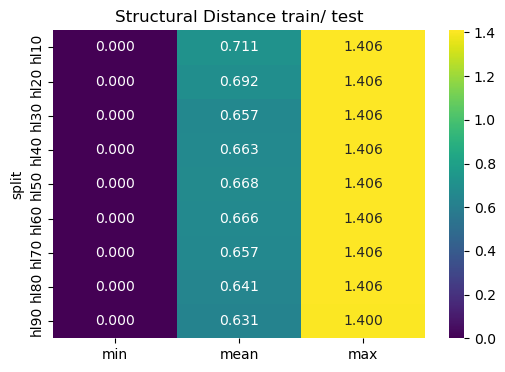

In [9]:
plt.figure(figsize=(6, 4))
sns.heatmap(
    df_stats.set_index("split"),
    annot=True, fmt=".3f",
    cmap="viridis",
    vmin=0, vmax=1.41
)
plt.title("Structural Distance train/ test")
plt.ylabel("split")
plt.savefig(save_path+"heatmap_stats.pdf")
plt.show()


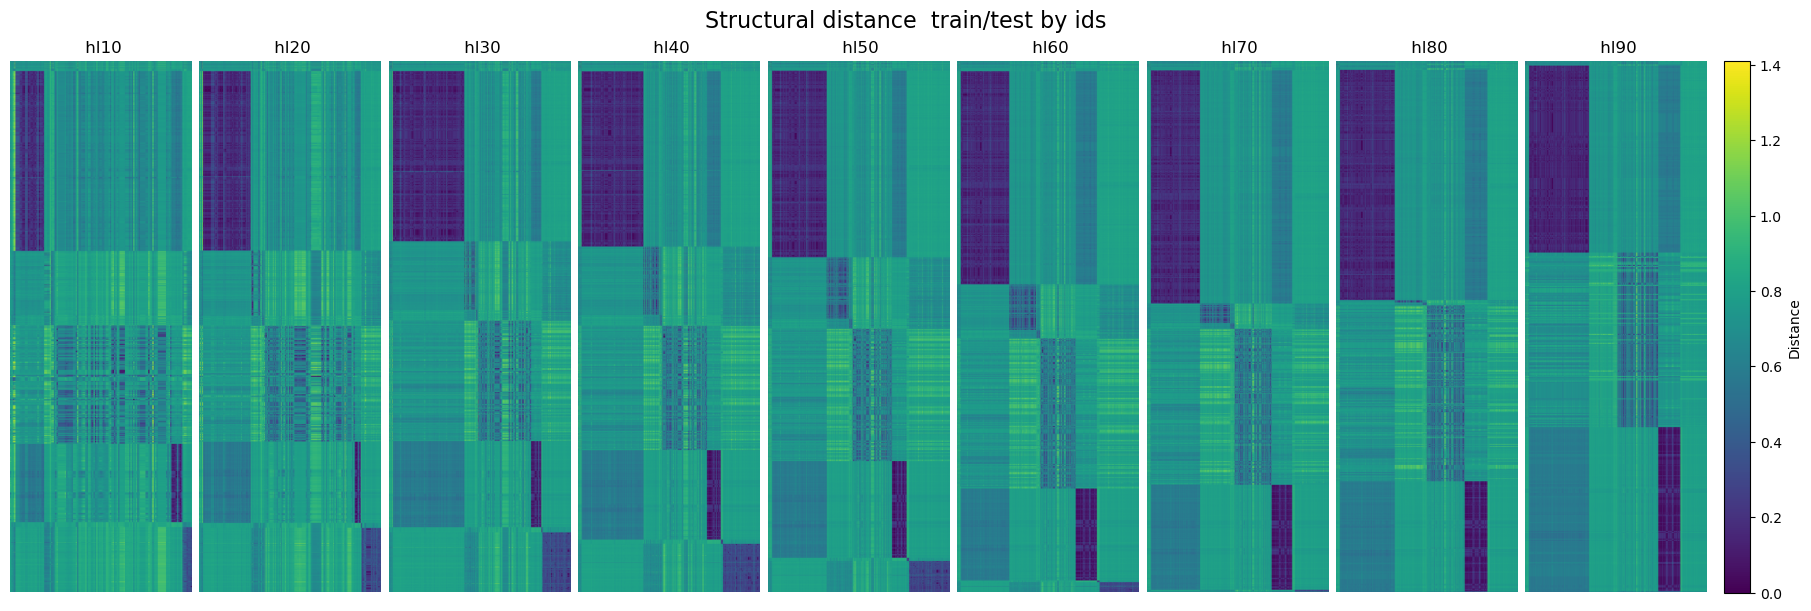

In [ ]:

fig, axes = plt.subplots(1, 9, figsize=(18, 6), constrained_layout=True)

vmin, vmax = 0, 1.41  # escala fija
for i,split in enumerate(splits_list):
    mat = dfs[split]['train']['test']
    im = axes[i].imshow(mat.values, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
    axes[i].set_title(f" {split[6:-9]}")
    axes[i].axis('off')  # quita los ticks/labels

# agregar barra de color única
cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label("Distance")

plt.suptitle("Structural distance  train/test by ids", fontsize=16)
plt.savefig(save_path+"heatmap_ids.pdf")
plt.show()


/tmp/ipykernel_1382815/2111616569.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(fams))
/tmp/ipykernel_1382815/2111616569.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(fams))
/tmp/ipykernel_1382815/2111616569.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(fams))
/tmp/ipykernel_1382815/2111616569.py:13: MatplotlibDeprecationWarning: The g

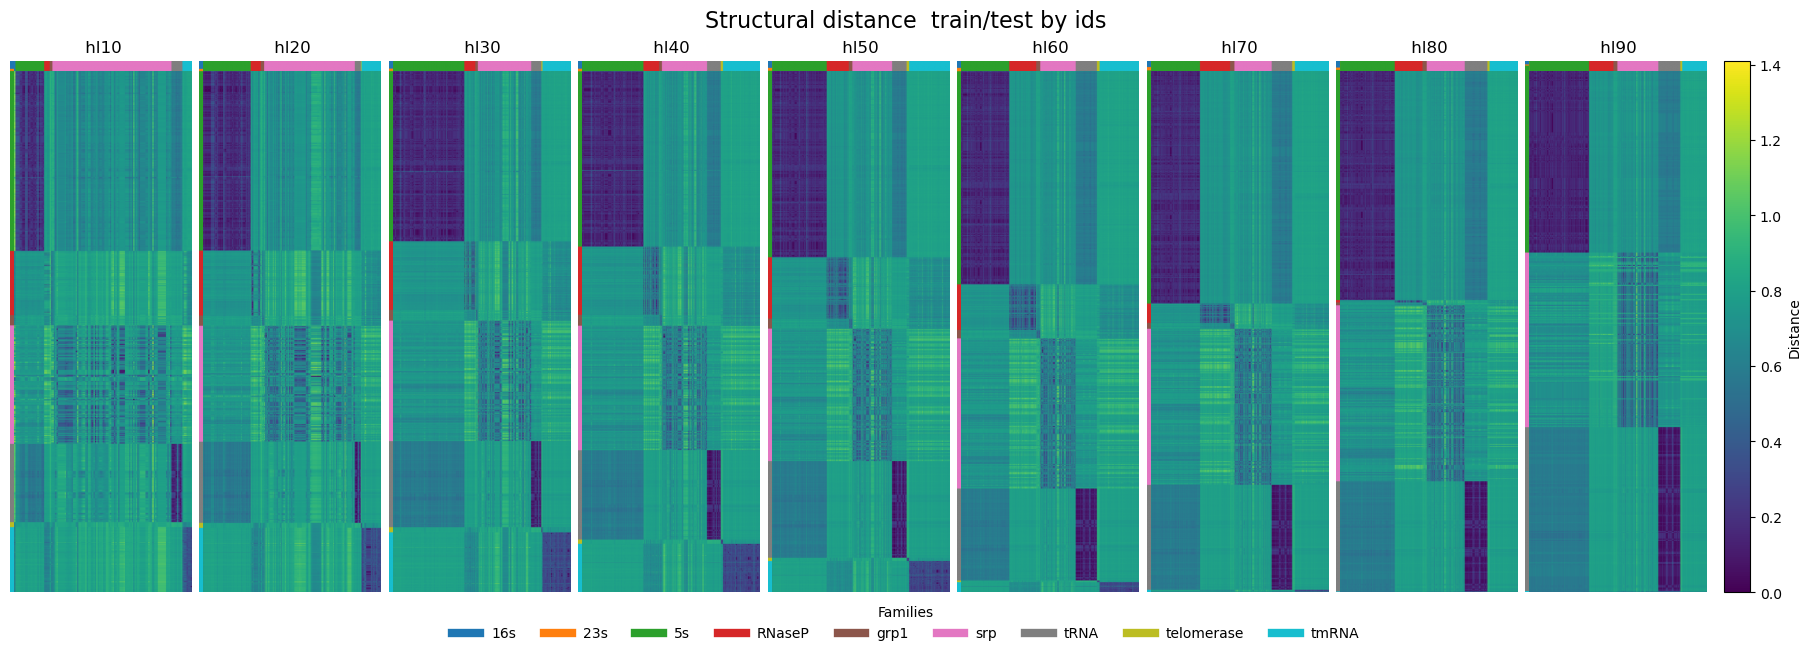

In [ ]:

from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
fig, axes = plt.subplots(1, 9, figsize=(18, 6), constrained_layout=True)

vmin, vmax = 0, 1.41  # escala fija
for i,split in enumerate(splits_list):
     
    splits[split]["fam"] = splits[split]["id"].str.split("_").str[0]
    id2fam = dict(zip(splits[split]["id"], splits[split]["fam"]))

    # paleta de colores (Set3 es buena para categorías)
    fams = sorted(set(id2fam.values()))
    cmap = plt.cm.get_cmap("tab10", len(fams))
    fam2color = {fam: cmap(i) for i, fam in enumerate(fams)}
    
    mat = dfs[split]['train']['test']
    im = axes[i].imshow(mat.values, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
    axes[i].set_title(f" {split[6:-9]}")
    axes[i].axis('off')  # quita los ticks/labels
    

    # familias filas y columnas → colores
    row_colors = [fam2color[id2fam[i]] for i in mat.index]
    col_colors = [fam2color[id2fam[i]] for i in mat.columns]

    # barrita arriba (columnas)
    ax_top = inset_axes(axes[i], width="100%", height="2%", loc="upper center",
                        bbox_to_anchor=(0, 0, 1, 1), bbox_transform=axes[i].transAxes, borderpad=0)
    ax_top.imshow([col_colors], aspect="auto")
    ax_top.axis("off")

    # barrita izquierda (filas)
    ax_left = inset_axes(axes[i], width="2%", height="100%", loc="center left",
                         bbox_to_anchor=(0, 0, 1, 1), bbox_transform=axes[i].transAxes, borderpad=0)
    ax_left.imshow(np.array(row_colors)[:, None].reshape(-1, 1, 4), aspect="auto")
    ax_left.axis("off")

# agregar barra de color única
cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label("Distance")


# leyenda de familias
handles = [plt.Line2D([0], [0], color=fam2color[f], lw=6) for f in fams]
# leyenda abajo, centrada, con varias columnas
fig.legend(handles, fams, title="Families", bbox_to_anchor=(0.5, -0.08), loc='lower center', ncol=len(fams), frameon=False, fontsize=10)

plt.suptitle("Structural distance  train/test by ids", fontsize=16)
# plt.savefig(save_path+"heatmap_ids.pdf")
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes



fig, axes = plt.subplots(1, 5, figsize=(18, 6), constrained_layout=True)

vmin, vmax = 0, 1.41
for fold in range(5):
    mat = dfs[fold]['train']['test']  # dataframe con index/columns = ids
    im = axes[fold].imshow(mat.values, cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
    axes[fold].set_title(f"Fold {fold}")
    axes[fold].axis("off")

    # familias filas y columnas → colores
    row_colors = [fam2color[id2fam[i]] for i in mat.index]
    col_colors = [fam2color[id2fam[i]] for i in mat.columns]

    # barrita arriba (columnas)
    ax_top = inset_axes(axes[fold], width="100%", height="2%", loc="upper center",
                        bbox_to_anchor=(0, 0, 1, 1), bbox_transform=axes[fold].transAxes, borderpad=0)
    ax_top.imshow([col_colors], aspect="auto")
    ax_top.axis("off")

    # barrita izquierda (filas)
    ax_left = inset_axes(axes[fold], width="2%", height="100%", loc="center left",
                         bbox_to_anchor=(0, 0, 1, 1), bbox_transform=axes[fold].transAxes, borderpad=0)
    ax_left.imshow(np.array(row_colors)[:, None].reshape(-1, 1, 4), aspect="auto")
    ax_left.axis("off")

# colorbar única para el heatmap
cbar = fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.01)
cbar.set_label("Distance")

# leyenda de familias
handles = [plt.Line2D([0], [0], color=fam2color[f], lw=6) for f in fams]
# leyenda abajo, centrada, con varias columnas
fig.legend(handles, fams, title="Families", bbox_to_anchor=(0.5, -0.08), loc='lower center', ncol=len(fams), frameon=False, fontsize=10)

plt.suptitle("Structural distance train/test by families", fontsize=16)
plt.show()


KeyError: 'id'

In [11]:
dfs_dists = {}

for split in splits_list:
    rows = []
    for part1, dic in dfs[split].items():
        for part2, mat in dic.items():
            # solo analizamos train/test (part1 != part2)
            if part1 != part2:
                vals = mat.to_numpy().ravel()
                rows.extend({
                    "part1": part1,
                    "part2": part2,
                    "dist": float(v)
                } for v in vals)

    dfs_dists[split] = pd.DataFrame(rows)

# ejemplo: muestro 5 filas
dfs_dists[split].sample(5)


,part1,part2,dist
411940,test,train,0.527273
3206264,train,test,0.762658
788661,test,train,0.902834
1997368,train,test,0.805014
2224325,train,test,0.743094


/tmp/ipykernel_1713794/1438030489.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', n_splits)
/tmp/ipykernel_1713794/1438030489.py:24: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


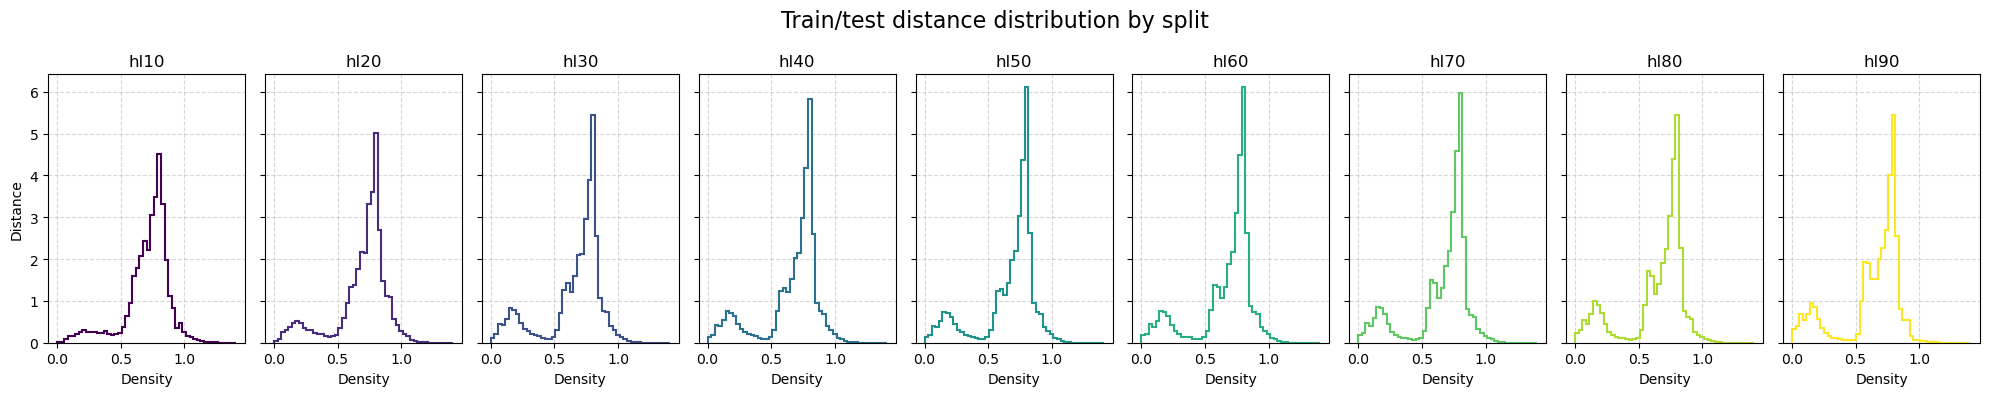

In [15]:


n_splits = len(splits_list)
cmap = cm.get_cmap('viridis', n_splits)
colors = [cmap(i) for i in range(n_splits)]

fig, axes = plt.subplots(1, n_splits, figsize=(20, 4), constrained_layout=True, sharex=True, sharey=True)

for i, split in enumerate(splits_list):
    df = dfs_dists[split]
    axes[i].hist(
        df['dist'],
        bins=50,
        density=True,
        histtype='step',
        color=colors[i],
        linewidth=1.5
    )
    axes[i].set_title(f"{split[6:-9]}") 
    axes[i].set_ylabel("")
    axes[i].set_xlabel("Density")
    axes[i].grid(True, ls="--", alpha=0.5)

axes[0].set_ylabel("Distance")
plt.suptitle("Train/test distance distribution by split", fontsize=16)
plt.tight_layout()
plt.savefig(save_path+"hist_subplots.pdf")
plt.show()


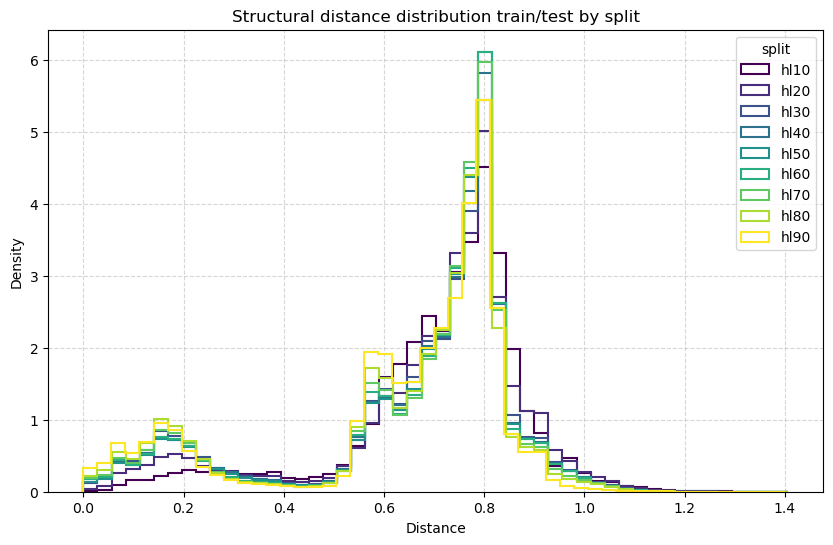

In [13]:
plt.figure(figsize=(10, 6))

for i, split in enumerate(splits_list):
    df = dfs_dists[split]
    plt.hist(
        df['dist'],
        bins=50,
        density=True,
        histtype='step',
        color=colors[i],
        linewidth=1.5,
        label=f"{split[6:-9]}"
    )


plt.title("Structural distance distribution train/test by split")
plt.xlabel("Distance")
plt.ylabel("Density")
plt.grid(True, ls="--", alpha=0.5) 
plt.legend(title="split")
plt.savefig(save_path+"hist.pdf")
plt.show()


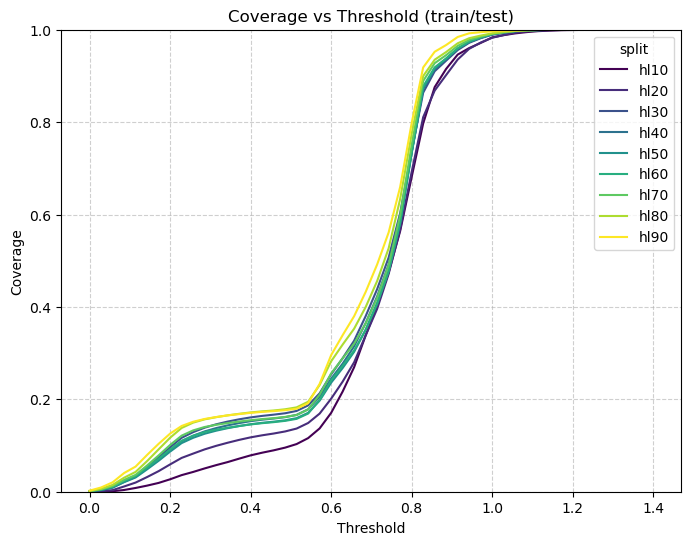

{'split_hl10-fold.csv': 0.09937669152780101, 'split_hl20-fold.csv': 0.13352326119977037, 'split_hl30-fold.csv': 0.172229807995646, 'split_hl40-fold.csv': 0.16371479492637947, 'split_hl50-fold.csv': 0.15677957813810553, 'split_hl60-fold.csv': 0.15546670297484014, 'split_hl70-fold.csv': 0.16387839735599027, 'split_hl80-fold.csv': 0.18043895492013956, 'split_hl90-fold.csv': 0.1778984101406975}


In [14]:
thresholds = np.linspace(0, 1.4, 50) 

plt.figure(figsize=(8, 6))
cover_metric = {}
for i, split in enumerate(splits_list):
    mat = dfs[split]['train']['test']
    vals_dist = mat.values.ravel()
    cover_metric[split] = (vals_dist <= 0.5).mean().item()
    coverage = [(vals_dist <= t).mean() for t in thresholds]
    plt.plot(
        thresholds,
        coverage,
        label=f"{split[6:-9]}",
        color=colors[i]
    )


plt.title("Coverage vs Threshold (train/test)")
plt.xlabel("Threshold")
plt.ylabel("Coverage")
plt.grid(True, ls="--", alpha=0.6)
plt.ylim(0, 1)
plt.legend(title="split")
plt.savefig(save_path+"coverage.pdf")

plt.show()
print(cover_metric)